[[81.96548045 82.1404535  79.27005083 71.05005445 74.046626  ]
 [60.59726667 62.44406876 52.67940526 85.21524689 83.86965752]
 [48.75796683 63.56430474 67.80668736 62.53793717 67.30195389]
 [48.92385825 54.35380796 61.26447808 58.15934313 61.80097254]
 [74.34712752 68.60796081 70.17485127 75.63800026 65.53747106]
 [59.04506737 72.58002114 68.93290233 72.98027846 70.31508069]
 [79.14249856 67.18005643 77.30701486 72.07479449 65.45729724]
 [84.7682704  76.22252939 76.77416047 65.61431457 74.8697678 ]
 [51.37388891 59.85783707 51.88077093 56.21286045 52.71918494]
 [77.78033877 81.69677625 81.47416142 71.65422722 68.03572543]
 [69.06522004 62.4236184  68.16924076 61.22077789 62.54516938]
 [51.55853386 67.54409441 59.47451029 64.02780178 64.49791458]
 [65.21668533 61.48624923 68.98655844 56.03042962 59.15702027]
 [85.3268166  84.16243266 77.27001366 83.60977802 75.68739287]
 [65.79151118 65.6195584  69.76976761 63.27783924 66.49196368]
 [72.3366973  64.70214069 75.49727178 55.21829488 60.20

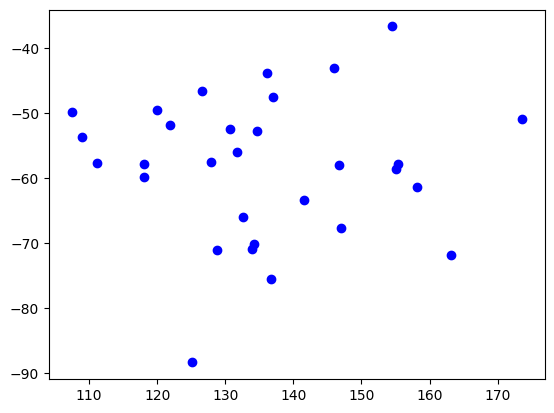

In [28]:
import numpy as np
import random as rd
import matplotlib.pyplot as plt 

n = 30

tec = np.random.normal(70, 10,n)                   # np.random.normal(media,desviacion,n)
crea = np.random.normal(65,10,n)

x1 = tec + np.random.normal(0,5,n)
x2 = tec + np.random.normal(0,5,n)
x3 = tec + np.random.normal(0,5,n)

x4 = crea  + np.random.normal(0,5,n)
x5 = crea + np.random.normal(0,5,n)

X = np.vstack([x1,x2,x3,x4,x5]).T      # vertical stack apilando arreglos
print(X)
u = np.mean(X,axis=0)
X_ = X - u                               # X- u   centrado de datos
cov = X_.T @ X_/n                        # COVARIANZA
print(cov)
val , vec = np.linalg.eig(cov)          # valores y vectores propios
arr = [1,4,2]
def ordenar_indices(arr):              # ordena y obtiene los indices 
    n = len(arr)
    ind = list(range(n))
    arr_ = arr.copy()
    for i in range(n-2,-1,-1):
        a = arr_[i]
        id_ = ind[i]
        j = i + 1
        while j<=n-1 and arr_[j]>a:
            arr_[j - 1] = arr_[j]
            ind[j - 1] = ind[j]
            j = j + 1
        arr_[j - 1] = a
        ind[j - 1] = id_
    return ind 
inds  = ordenar_indices(val) 
val_ =val[inds]                # lmayor, ...
vec_ = vec[:,inds]             # vmayor, v,,
#Col 1    Col 2    Col 3
#    ┌                          ┐
#    │  2.5      2.0     -3.0    │  <- Fila 1
#    │  3.5      3.0     -2.0   │  <- Fila 2
#Xc =│ -3.5     -2.0      3.0   │  <- Fila 3
#    │ -2.5     -3.0      2.0   │  <- Fila 4
#    └                          ┘ 
#   v1​≈(0.63,0.52,−0.58)
#  PC1​=0.63(Mate)+0.52(Fıˊsica)−0.58(Comunicacioˊn)

# proyeccion 
#  X v1  =   DATOS CENTRADOS (Xc)               PROYECCIÓN PCA (Z)
#    Col 1    Col 2    Col 3               PC1 (Varianza Máx)
#  ┌                          ┐                ┌        ┐
#  │  2.5      2.0     -3.0   │       ─────▶   │  4.36  │  Persona A
#  │  3.5      3.0     -2.0   │0.63    ─────▶  │  4.92  │  Persona B
#  │ -3.5     -2.0      3.0   │0.52    ─────▶  │ -4.98  │  Persona C
#  │ -2.5     -3.0      2.0   │-0.58   ─────▶  │ -4.29  │  Persona D
#  └                          ┘                └        ┘
#    (3D: Espacio original)             (1D: Resumen)
print(vec_[0])
por = [ v/sum(val_) for v in val_] 
print(por)
z1 = X@vec_[:,0]
z2 = X@vec_[:,1]
plt.scatter(z1,z2,color='blue')
plt.show() 

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.

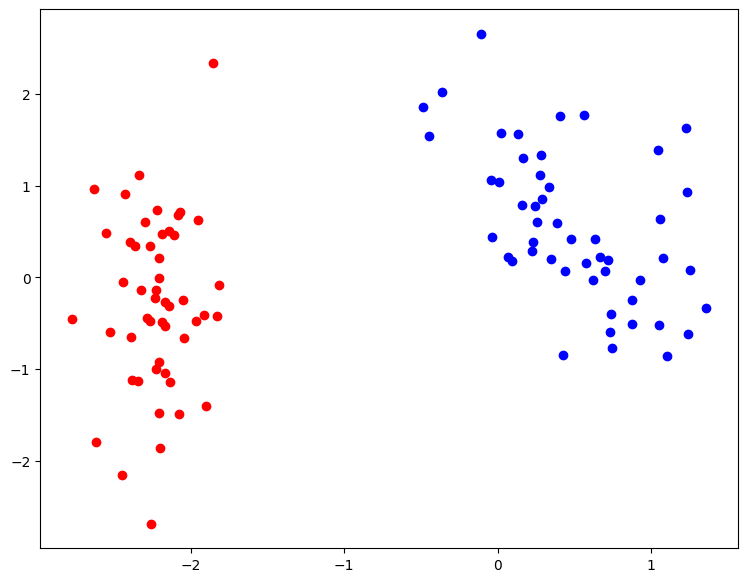

[np.float64(72.96244541329993), np.float64(22.85076178670174), np.float64(3.6689218892828674), np.float64(0.5178709107154726)]


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.datasets import load_iris

class PCA:
    #----------------------------------
    def __init__(self):
        self.k = 2
        self.val = None
    #----------------------------------
    def ordenar_indices(self,v):
        n = len(v)
        inds = list(range(n))
        v_ = v.copy()
        for i in range(n-2,-1,-1):
            dat = v_[i]
            id_ = inds[i]
            j = i + 1
            while j<=n-1 and v_[j]>dat:
                v_[j - 1 ] = v_[j]
                inds[j - 1] = inds[j]
                j = j + 1
            v_[j - 1] = dat
            inds[j - 1 ]  =id_
        return inds
    #-----------------------------------
    def transformar_entrenar(self,X):
        n,_ = X.shape
        u = X.mean(axis=0)
        sigma = X.std(axis=0)
        X_ = X.copy()
        X_ = (X - u )/sigma
        cov = X_.T @ X_ / n
        val , vec = np.linalg.eig(cov)
        print(f"val  {val}")
        inds = self.ordenar_indices(val)
        val_ = val[inds]
        self.val = val_
        vec_  = vec[:,inds]              # v1 ,v2
        z = X_ @ vec_[:,:self.k]    # proyeccion
        return z                  #pc1,pc2  
    #--------------------------------------
    def porcentaje_explicado(self):
        val = self.val
        porcentajes = [(v/val.sum())*100 for v in val]
        return porcentajes
    #------------------------------------------
    def graficar(self,z,y):
        plt.figure(figsize=(9,7))
        mascara = y == 0             # filas con etiqueta 0
        z1 = z[mascara,0]         # filas que cumplen , columa 0
        z2 = z[mascara,1]
        plt.scatter(z1,z2,color='red')
        mascara = y ==1
        z1_ = z[mascara,0]
        z2_ = z[mascara,1]
        plt.scatter(z1_,z2_,color='blue')
        plt.show()
    #-----------------------------------------
    
#=================================================
if __name__=='__main__':
    pca = PCA()
    #data = load_breast_cancer()
    data = load_iris()
    X = data.data
    y = data.target
    print(X)
    print(y)
    z = pca.transformar_entrenar(X)
    pca.graficar(z,y)
    porcentajes = pca.porcentaje_explicado()
    print(porcentajes)


 {'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]], shape=(569, 30)), 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 

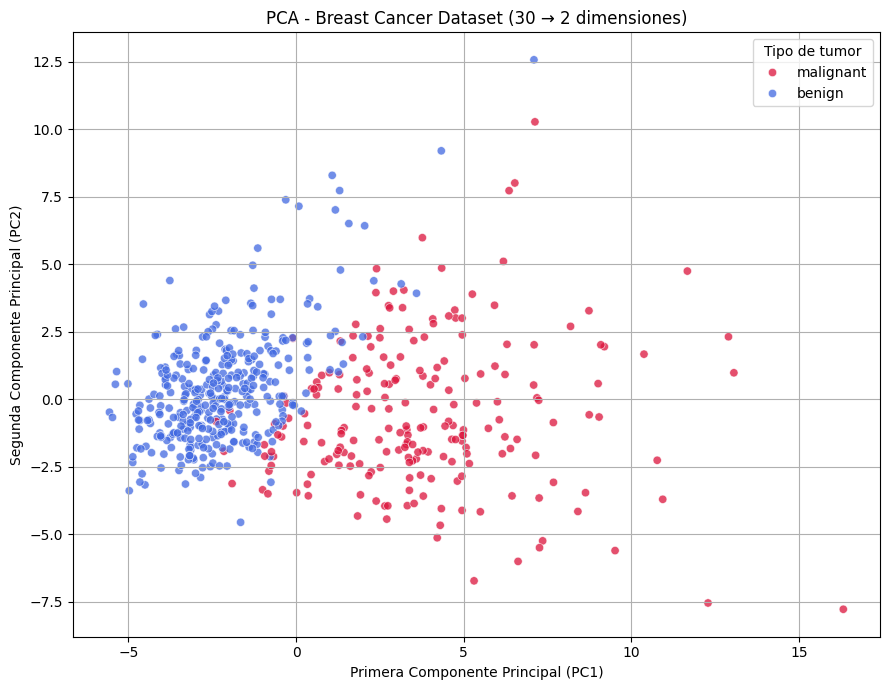

In [4]:
#SKLEARN
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
# Cargar dataset
data = load_breast_cancer()
print("\n",data)                                                                                                                          
X = data.data          # (569, 30)
y = data.target        # 0 = maligno, 1 = benigno
target_names = data.target_names
print("\n\n",target_names)
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2, random_state=42)) 
])
X_pca = pipeline.fit_transform(X)
pca = pipeline.named_steps["pca"]

print("Varianza explicada por componente:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {var:.4f}")

print(f"\nVarianza total explicada: {pca.explained_variance_ratio_.sum():.4f}")
plt.figure(figsize=(9, 7))

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=[target_names[i] for i in y],
    palette=["crimson", "royalblue"],
    alpha=0.75
)

plt.title("PCA - Breast Cancer Dataset (30 → 2 dimensiones)")
plt.xlabel("Primera Componente Principal (PC1)")
plt.ylabel("Segunda Componente Principal (PC2)")
plt.legend(title="Tipo de tumor")
plt.grid(True)
plt.tight_layout()
plt.show()



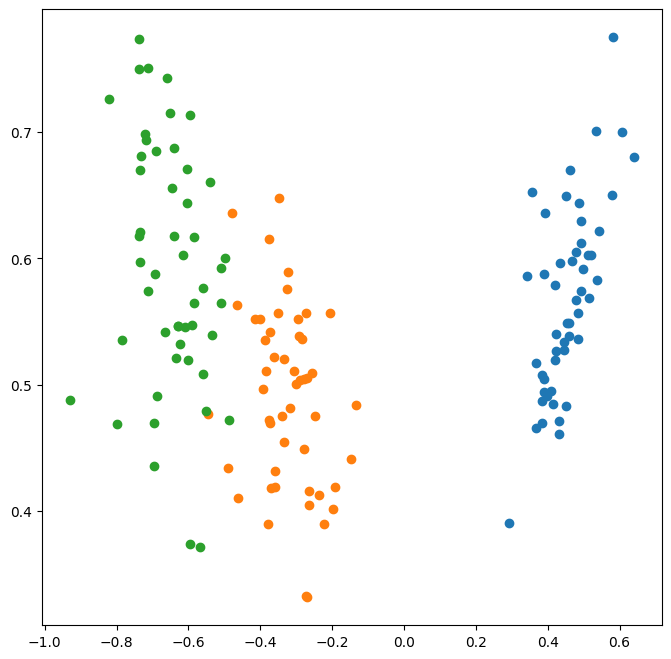

In [2]:
# LDA
import numpy as np
from sklearn.datasets import load_iris
from scipy.linalg import eigh
#============================================================
class LDA:
    #-------------------------------------------------------
    def __init__(self,k):
        self.k = k
        self.X = None
        self.y = None
        self.val = None
        self.z = None
        self.clases = None
    #------------------------------------------------------
    def determinar_clases(self,Y):
        clases = []
        for y in Y:
            if y not in clases:
                clases.append(y)
        self.clases = clases
        self. k = len(clases)
        return clases                   # 0,1...
# id X1  X2  Clase
# 0  2   3    0
# 1  3   3    0
# 2  2   4    0
# 3  5   2    1
# 4  6   2    1   mascara = [0,1,2] clase 0
# 5  6   3    1
    #-------------------------------------------------------
    def medias_k(self,clases,X,y):
        #clases = self.clases(y)
        medias_k = [0]*len(clases)
        for i,c in enumerate(clases):
            mascara = y == c
            medias_k[i] = X[mascara].mean(axis = 0)
        return medias_k
    #------------------------------------------------------
    def dispersion_intra_clases(self,X,y,medias_k):
        m, n = X.shape
        clases = self.determinar_clases(y)
        #medias_k = medias_k(clases,X,y)
        SW = np.zeros((n,n))
        for i,c in enumerate(clases):
            xc_uc = X[y==c] - medias_k[i]
            SWc = xc_uc.T @ xc_uc
            SW +=SWc
        return SW
#
# SW = SW0 + SW1 = |1.34  -0.66|
#                  |-0.66 1.34|
    #------------------------------------------------------
    def n_s(self,clases,X,y):
        n_s = [0]*len(clases)
        for i,c in enumerate(clases):
            mascara = y ==c
            n_s[i] = len(X[mascara])
        return n_s
    #-------------------------------------------------------
    def dispersion_inter_clases(self,X,y,medias_k):
        u = X.mean(axis = 0)
        m ,n = X.shape
        SB = np.zeros((n,n))
        clases = self.determinar_clases(y)
        n_s = self.n_s(clases,X,y)
        for i,c in enumerate(clases): 
            uk_u = (medias_k[i] - u).reshape(n,1)
            SB_c = n_s[i] * uk_u @ uk_u.T
            SB +=SB_c
        return SB
# SB = SB0 + SB1 = |16.74 -5.01|
#                  |-5.01 1.5 |
    #--------------------------------------------------------
    def ordenar_indices(self,arr):
        n = len(arr)
        arr_ = arr.copy()
        inds = list(range(n))
        for i in range(n-2,-1,-1):
            e = arr_[i]
            ids = inds[i]
            j = i + 1
            while j<=n-1 and arr_[j]>e:     # [4, 2, 7, 1] ,  7 [1]
                arr_[j - 1] = arr_[j]
                inds[j - 1] = inds[j]
                j = j + 1
            arr_[j - 1] = e
            inds[j - 1] = ids
        return inds
    #--------------------------------------------------------
    def transformar_entrenar(self,X,y,normalizar='estandarizar'):
        self.X = X
        self.y = y
        clases = self.determinar_clases(y)
        medias_k = self.medias_k(clases,X,y)
        SW = self.dispersion_intra_clases(X,y,medias_k)
        SB = self.dispersion_inter_clases(X,y,medias_k)
        #val, vec = np.linalg.eig(np.linalg.inv(SW)@SB)
        val , vec = eigh(SB,SW)
        ids = self.ordenar_indices(val)
        z = X@vec[:,ids]  
        return z
    #-----------------------------------------------------
    def graficar(self,z):
        plt.figure(figsize=(8,8))
        for i,c in enumerate(self.clases):
            mascara = self.y == c
            z1 = z[mascara,0]
            z2 = z[mascara,1]
            plt.scatter(z1,z2)
        plt.show()
    #------------------------------------------------------
#=============================================================
if __name__=='__main__':
    data = load_iris()
    X, y = data.data, data.target 
    lda = LDA(k=2)
    z = lda.transformar_entrenar(X,y)
    lda.graficar(z)

In [5]:
# SKLEARN 

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.datasets import load_iris
data = load_iris()
X, y = data.data, data.target
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X, y)
print(f"Varianza explicada por componentes: {lda.explained_variance_ratio_}")


Varianza explicada por componentes: [0.9912126 0.0087874]


shape (150, 4)


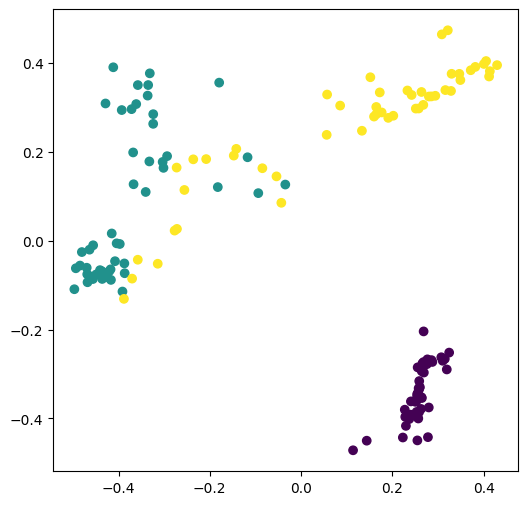

In [7]:
# corteria de gpt  , customizado a mi estilo

import numpy as np
from sklearn.datasets import make_swiss_roll
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

#=======================================================
class T_SNE:
    #-----------------------------------------------------------
    def __init__(self):
        return
    #-----------------------------------------------------------
    def distancias_(self,X):
        m,n = X.shape
        D = np.zeros((m,m))
        for i in range(m):
            for j in range(m):
                D[i,j] = np.sum((X[i]-X[j])**2)
        return D
    #-----------------------------------------------------------
    def distancias(self,X):  #||x||² + ||x||² − 2x·x
        m , n = X.shape
        sum_X = np.sum(X**2,axis=1)
        A = sum_X.reshape(m,1) 
        B = sum_X.reshape(1,m)
        D = A + B -2 *X@X.T
        return D
     #-------------------------------------------------------------
    def similitudes_espacio_original(self,D, sigma=1.0):
        m = D.shape[0]
        P = np.zeros((m,m))
        for i in range(m):
            z = 0
            for j in range(m):
                if i != j:
                    P[i,j] = np.exp(-D[i,j]/(2*sigma**2))
                    z += P[i,j]
            for j in range(m):
                if i!=j:
                    P[i,j]/=z
        P = (P + P.T) / (2*m)                                   # simetrizando (p(j|i) + p(i|j)) / 2N
        return P
    #-----------------------------------------------------------
    def similitudes_con_perplejidad(self,D,per=30,tol=1e-5,max_iter=50): 
        m = D.shape[0]
        P = np.zeros((m,m))
        logU = np.log(per)                   #Perplexity(Pi)=2^H(Pi),   H(Pi)=−j∑Pj∣i log2Pj∣i
        for i in range(m):
            beta = 1.0                               # beta = 1/(2*sigma^2)
            betamin = -np.inf
            betamax = np.inf
            Di = np.delete(D[i], i)  
            for _ in range(max_iter):
                # Numerador
                Pi = np.exp(-Di * beta)
                Z = Pi.sum()
                Pi /= Z
                # Entropía
                H = -np.sum(Pi*np.log(Pi))
                Hdiff = H - logU
                if abs(Hdiff) < tol:
                    break
                if Hdiff > 0:
                    betamin = beta
                    beta = beta*2 if betamax==np.inf else (beta+betamax)/2
                else:
                    betamax = beta
                    beta = beta/2 if betamin==-np.inf else (beta+betamax)/2
            # Poner en la matriz final
            idx = [j for j in range(m) if j != i]
            P[i, idx] = Pi
        return (P + P.T)/(2*m)
    #------------------------------------------------------------
    def probabilidades_espacio_reducido(self,Y):
        m = Y.shape[0]
        Q = np.zeros((m,m))
        for i in range(m):
            for j in range(m):
                if i != j:
                    Q[i,j] = 1 / (1 + np.sum((Y[i]-Y[j])**2))
        Q /= np.sum(Q)
        return Q
    #----------------------------------------------------------------
    def probabilidades_espacio_reducido_(self,Y):
        m,n = Y.shape
        sum_Y = np.sum(Y**2,axis=1)
        A = sum_Y.reshape(m,1)
        B = sum_Y.reshape(1,m)
        D = A + B - 2 * Y @ Y.T
        Q = 1 /(1 + D)
        np.fill_diagonal(Q,0)                # diagonal 0's
        Q /=np.sum(Q)
        return Q
    #------------------------------------------------------------
    def gradiente(self,P,Q,Y):
        m = Y.shape[0]
        dY = np.zeros_like(Y)
        for i in range(m):
            for j in range(m):
                if i != j:
                    dY[i] += 4*(P[i,j]-Q[i,j]) * (Y[i]-Y[j]) / (1 + np.sum((Y[i]-Y[j])**2))
        return dY
    #-----------------------------------------------------------------------------------
    def gradiente_(self,P,Q,Y):                   # optimizado, entender luego
        sum_Y = np.sum(Y**2, axis=1)
        D = sum_Y[:,None] + sum_Y[None,:] - 2 * Y @ Y.T
        inv = 1 / (1 + D)
        np.fill_diagonal(inv, 0)
        PQ = (P - Q) * inv
        dY = 4 * (np.diag(np.sum(PQ, axis=1)) - PQ) @ Y
        return dY
    #--------------------------------------------------------------------------------
    def transformar_entrenar(self,X,N=500,lr =0.1,momentum=0.8):
        D = self.distancias(X)
        P = self.similitudes_con_perplejidad(D)
        m,n = X.shape
        Y = np.random.randn(m,2)*0.01
        Y_previo = Y.copy()
        for _ in range(N):
            Q = self.probabilidades_espacio_reducido_(Y)
            dy = self.gradiente_(P,Q,Y)                              # en lugar de movernos en direccion de gradiente,agregamos un empuje en la iteracion anterior
            Y_nuevo = Y - lr * dy + momentum*(Y - Y_previo )        #(t+1)=Y(t)−lr⋅∇C+momentum⋅(Y(t)−Y(t−1))
            Y_previo , Y = Y, Y_nuevo
        return Y
    #----------------------------------------------------------------------------------
    def graficar(self,Y,y):
        plt.figure(figsize=(6,6)) 
        plt.scatter(Y[:,0],Y[:,1],c = y)
        plt.show()
    #-----------------------------------------------------------------------
#==============================================================================================
if __name__=='__main__':
    #data = load_digits()
    data = load_iris()
    X, y = data.data, data.target
    print(f"shape {X.shape}")
    t_sne = T_SNE()
    Y = t_sne.transformar_entrenar(X)
    t_sne.graficar(Y,y)
    

C:\Users\USUARIO\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


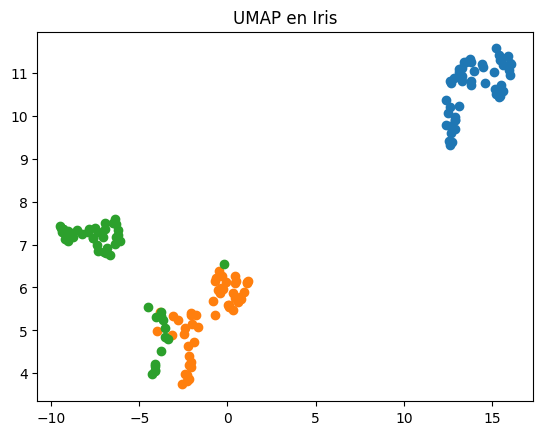

In [3]:
# UMAP 
# segun gpt es un algoritmo mas complejo 

import umap
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

data = load_iris()
X, y = data.data, data.target

modelo = umap.UMAP(
    n_neighbors=10,
    min_dist=0.1,
    n_components=2,
    random_state=42
)

X_umap = modelo.fit_transform(X)

for clase in np.unique(y):
    plt.scatter(X_umap[y==clase,0],
                X_umap[y==clase,1])

plt.title("UMAP en Iris")
plt.show()